<a href="https://colab.research.google.com/github/sechan-design/-R-/blob/class/ARIMAX_%EB%AA%A8%EB%8D%B8_4%EB%85%84_%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("forecast")
install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(forecast)
library(readr)

In [5]:
data <- read.csv('통합데이터.csv')
head(data)

,year,whole.popu,whole,elen.popu,elem,mid.popu,mid,high.popu,high
,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>
1,2007,7869,22.2,3808,22.7,2095,23.4,1966,19.7
2,2008,7740,23.3,3631,24.2,2070,24.1,2039,20.6
3,2009,7569,24.2,3446,24.5,2034,26.0,2089,21.7
4,2010,7349,24.0,3280,24.5,1985,25.5,2084,21.8
5,2011,7085,24.0,3109,24.1,1914,26.2,2062,21.8
6,2012,6821,23.6,2926,21.9,1867,27.6,2028,22.4


In [6]:
y <- ts(data$high, start =2007)
x <- ts(data$high.popu , start=2007)

In [7]:
model <-auto.arima( y, xreg=x )
summary(model)

Series: y 
Regression with ARIMA(2,0,1) errors 

Coefficients:
         ar1      ar2     ma1  intercept     xreg
      1.3815  -0.8153  0.3700    90.1232  -0.0345
s.e.  0.1845   0.1698  0.2663     6.0069   0.0034

sigma^2 = 2.033:  log likelihood = -32.88
AIC=77.76   AICc=84.76   BIC=83.43

Training set error measures:
                     ME     RMSE       MAE        MPE     MAPE      MASE
Training set 0.03618231 1.223819 0.9816638 0.03135628 3.117201 0.5106921
                     ACF1
Training set -0.004683523

In [8]:
#예측을 위해 x 값 예측
x_model <- auto.arima(x)
future_x <-forecast(x_model, h=4)$mean #4년 예측

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
2026       44.48925 42.66213 46.31636 41.69491 47.28358
2027       39.54960 35.86455 43.23464 33.91381 45.18538
2028       37.24539 32.53652 41.95427 30.04379 44.44699
2029       38.16930 33.24487 43.09372 30.63804 45.70056


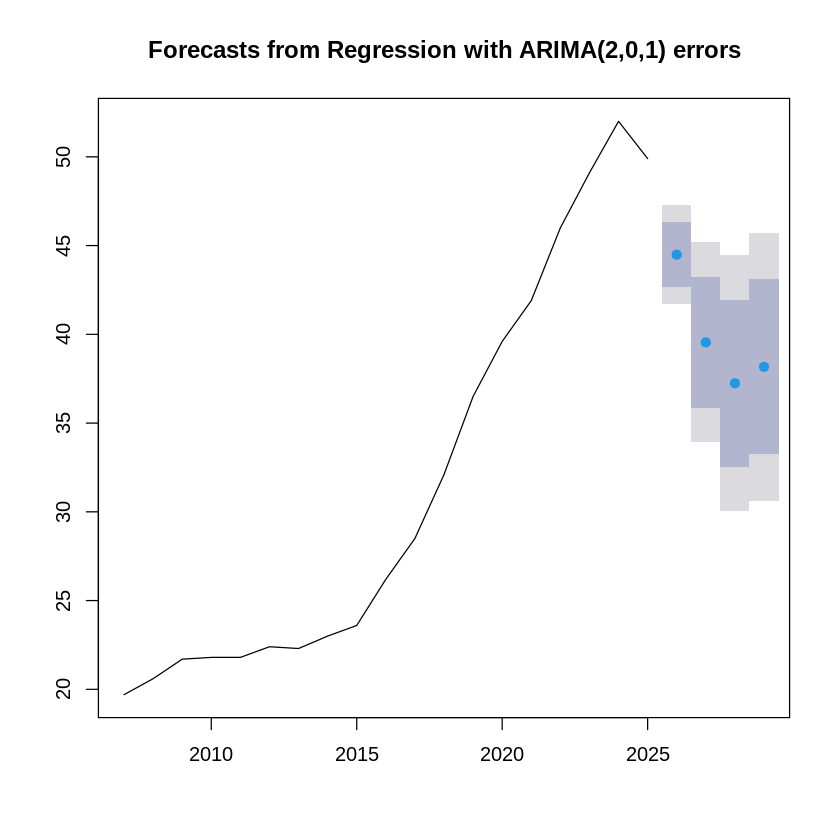

In [9]:
forecast_y <- forecast(model,xreg =future_x, h=4)

print(forecast_y)
plot(forecast_y)